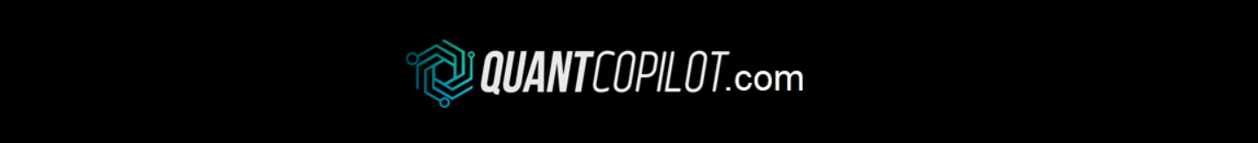

<font color='red'>**NOTA IMPORTANTE:**</font> Ya que el web data reader ha sido descontinuado, en este notebook se han reemplazado todas las instancias del web data reader, por el paquete **YFinance**. Todo lo demás es exactamente como en los videos del curso.

In [ ]:
pip install yfinance

In [2]:
import yfinance as yf

In [3]:
# Data desde el Drive 
# data = pd.read_csv("--ruta-del-archivo--") 

# Data desde Yahoo
asset = 'AMZN'
start_date = '2015-01-01'
end_date = '2021-01-01'
data = yf.download(asset, interval="1d", start=start_date, end=end_date)

[*********************100%***********************]  1 of 1 completed


In [4]:
data

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2015-01-02,312.500000,314.750000,306.960114,308.519989,308.519989,2788101
2015-01-05,307.019989,308.380005,300.850006,302.190002,302.190002,2774231
2015-01-06,302.200012,303.000000,292.380005,295.290009,295.290009,3519034
2015-01-07,297.540009,301.279999,295.329987,298.420013,298.420013,2640349
2015-01-08,300.589996,303.140015,296.109985,300.459991,300.459991,3088398
...,...,...,...,...,...,...
2020-12-24,3193.899902,3202.000000,3169.000000,3172.689941,3172.689941,1451917
2020-12-28,3194.000000,3304.000000,3172.689941,3283.959961,3283.959961,5686787
2020-12-29,3309.939941,3350.649902,3281.222900,3322.000000,3322.000000,4872933


In [ ]:
# # Convirtiendo Date column (str) to DateTime
# data['Date'] = pd.to_datetime(data['Date'])

# # Estableciendo la columna 'Date' como el Index
# data = data.set_index('Date')

In [5]:
data.head(3)

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2015-01-02,312.500000,314.750000,306.960114,308.519989,308.519989,2788101
2015-01-05,307.019989,308.380005,300.850006,302.190002,302.190002,2774231
2015-01-06,302.200012,303.000000,292.380005,295.290009,295.290009,3519034


------
# Visualizando Datos con Plotly

In [6]:
import plotly.graph_objects as go

<font color='red'>**NOTA IMPORTANTE:**</font> En en el curso se menciona usar una funcion para poder visualizar los graficos de plotly en Google Colab. Actualmente ese error de Google Colab ha sido arreglado. Ya no hace falta la funcion (como se ve en este Notebook).

In [8]:
fig = go.Figure()

fig.add_trace(go.Scatter(x=data.index,
                         y=data['Close']
                         )
)
              
# fig.update_layout(showlegend=True)

fig.show()

In [9]:
fig = go.Figure()

fig.add_trace(go.Bar(x=data.index, y=data['Open']))

fig.show()

## Ploteando OHLC - Candlesticks (Velas)

In [10]:
fig = go.Figure()

fig.add_trace(go.Candlestick(
                             x=data.index, # Plotly por defecto ploteara TODOS los DÍAS DEL CALENDARIO, incluyendo Fines de semana.
                             open = data['Open'],
                             high = data['High'],
                             low = data['Low'],
                             close = data['Adj Close']
                             ))
              

fig.update_layout(xaxis_rangeslider_visible=False)

fig.show()


## Cambiando los colores

In [11]:
fig = go.Figure()

fig.add_trace(go.Candlestick(
                             x=data.index,
                             open = data['Open'],
                             high = data['High'],
                             low = data['Low'],
                             close = data['Close'],
                             increasing_line_color= 'cyan',
                             decreasing_line_color= 'gray'
                             ))


fig.update_layout(xaxis_rangeslider_visible=False)

fig.show()


## Anadiendo textos y etiquetas a un grafico

In [12]:

fig = go.Figure()

fig.add_trace(go.Scatter(x=data.index,
                         y=data['Close'], 
                         name="Precio Linea Purpura",
                         fill='tozeroy', # Llena de color desde el precio hasta abajo
                         mode='none' # Sobreescribe el predeterminado 'markers+lines'
                         )
)

fig.update_layout(
    showlegend=True
    )

fig.show()

In [13]:

fig = go.Figure()

fig.add_trace(go.Scatter(x=data.index,
                         y=data['Close'], 
                         name="Precio Linea Purpura",
                        #  fill='tozeroy', # Llena de color desde el precio hasta abajo
                        #  mode='none' # Sobreescribe el predeterminado 'markers+lines'
                         )
)
         

fig.update_layout(
    showlegend=True,
    autosize=False,
    width=900,
    height=600, 
    template="plotly_white",
    # template="plotly_dark",
    # template="ggplot2",
    # template="seaborn",
    # template="simple_white",
    # template="none",
    # margin=dict(
    #     l=200, 
    #     r=200, 
    #     t=200, 
    #     b=200),
    title=go.layout.Title(
        text="<b><i>Mi Titulo en Negrita</i></b> - Mi titulo en Simple", # titulo
        xref="paper", # referencia desde donde empieza el titulo
        x=0.5, # Centra el titulo
        font=dict(
            size=18,
            color="blue",
            family="Helvetica",
            )
    ),
    xaxis=go.layout.XAxis(        
        title=go.layout.xaxis.Title(
            text="Este es mi Titulo en el axis X"
        )
    ),
    yaxis=go.layout.YAxis(
        title=go.layout.yaxis.Title(
            text="Este es mi Titulo en el axis Y"
        )
    )
)


fig.show()

## Anadiendo Subplots


In [14]:
from plotly.subplots import make_subplots

In [15]:

fig = make_subplots(rows=2, cols=1, 
                    row_heights=[0.8, 0.2], 
                    shared_xaxes=True, 
                    # subplot_titles=("Plot 1", "Plot 2"),
                    # vertical_spacing=0.02 # Tight vertical spacing
                    )

fig.add_trace(go.Candlestick(
                            #  x=data.index, # Plotly por defecto ploteara TODOS los DÍAS DEL CALENDARIO, incluyendo Fines de semana.
                             x=data.index.strftime("%Y/%m/%d"), # Para evitar trazar todos los días del calendario, convertimos el índice en una cadena
                             open = data['Open'],
                             high = data['High'],
                             low = data['Low'],
                             close = data['Close'],
                             name="Open/Close"
                             ),
              row=1, col=1)
               
                    
fig.add_trace(go.Bar(
                    #  x=data.index, 
                     x=data.index.strftime("%Y/%m/%d"),
                     y=data['Volume'],
                     name="Volume"
                     ),
              row=2, col=1)


fig.update_layout(xaxis_rangeslider_visible=False,                  
                  showlegend=True,
                  autosize=False,
                  width=900,
                  height=600,
                  template="plotly_white",     
                  )  

fig.show()


## Precio y Volumen en el Mismo grafico 
*(multiple axes)*

In [16]:

fig = make_subplots(specs=[[{"secondary_y": True}]])

fig.add_trace(go.Candlestick(
                             x=data.index,
                             open = data['Open'],
                             high = data['High'],
                             low = data['Low'],
                             close = data['Close'],
                             name="Open/Close"
                             )
              ,secondary_y=True
              )

# fig.add_trace(go.Scatter(x=data.index, y=data['Close'], line=dict(color='blue', width=1), name="Precio de Cierre"),secondary_y=True)

fig.add_trace(go.Bar(x=data.index, y=data['Volume'], name="Volume"), secondary_y=False)

fig.layout.yaxis.color = 'red'

fig.update_layout(xaxis_rangeslider_visible=False, template="plotly_white")

fig.show()


## Anadiendo Textos y Etiquetas a los Subplots

In [17]:

fig = make_subplots(rows=2, cols=1, 
                    row_heights=[0.8, 0.2], 
                    shared_xaxes=True, 
                    subplot_titles=("Plot 1", "Plot 2"),
                    # vertical_spacing=0.02 # Espacio vertical
                    )

fig.add_trace(go.Candlestick(
                            #  x=data.index, 
                             x=data.index.strftime("%Y/%m/%d"),
                             open = data['Open'],
                             high = data['High'],
                             low = data['Low'],
                             close = data['Close'],
                             name="Open/Close"
                             ),
              row=1, col=1)
               
                    
fig.add_trace(go.Bar(
                    #  x=data.index, 
                     x=data.index.strftime("%Y/%m/%d"),
                     y=data['Volume'],
                     name="Volume"
                     ),
              row=2, col=1)


fig.update_layout(xaxis_rangeslider_visible=False,                  
                  showlegend=True,
                  autosize=False,
                  width=900,
                  height=600     
                  )  

# Texto en el eje X
fig.update_xaxes(title_text="Titulo en Eje X - Grafico 1", row=1, col=1)
fig.update_xaxes(title_text="Titulo en Eje X - Grafico 2", row=2, col=1)

# Texto en el eje Y
fig.update_yaxes(title_text="Titulo en Eje Y - Grafico 1", row=1, col=1)
fig.update_yaxes(title_text="Titulo en Eje Y - Grafico 2", row=2, col=1)

fig.show()


## Anadiendo Figuras y Anotaciones

In [18]:

fig = go.Figure()

fig.add_trace(go.Candlestick(
                             x=data.index,
                             open = data['Open'],
                             high = data['High'],
                             low = data['Low'],
                             close = data['Close']
                             ))


fig.update_layout(
    shapes = [dict(
        x0='2018-12-01', 
        x1='2019-06-01', 
        y0=0, 
        y1=1, 
        xref='x', 
        yref='paper',
        fillcolor='LightSkyBlue',
        opacity=0.5,
        line_width=1)],
    annotations=[dict(
        x='2018-12-01',
        y=0.1, 
        yref='paper',
        showarrow=False,
        xanchor='left',
        text='Mi Anotacion'
        )]
)

fig.update_layout(xaxis_rangeslider_visible=False)
fig.show()

## Anadiendo Medias Moviles *(Simples y Exponenciales)*

In [19]:
# MM Normal
data['MA20'] = data['Close'].rolling(20).mean()
data['MA150'] = data['Close'].rolling(150).mean()

# MM Exponencial
data['MA20-E'] = data['Close'].ewm(span=20).mean()
data['MA150-E'] = data['Close'].ewm(span=150).mean()

In [20]:

fig = go.Figure()

fig.add_trace(go.Candlestick(
                             x=data.index, 
                             open = data['Open'],
                             high = data['High'],
                             low = data['Low'],
                             close = data['Adj Close']                             
                             )              
)

fig.add_trace(go.Scatter(x=data.index, y=data['MA20'], line=dict(color='blue', width=1)))

fig.add_trace(go.Scatter(x=data.index, y=data['MA150'], line=dict(color='cyan', width=2)))


fig.update_layout(xaxis_rangeslider_visible=False)

fig.show()


##.

### Anadiendo senales de Compra o Venta
 *(Basadas en las Medias Moviles)*

SOURCE: https://towardsdatascience.com/making-a-trade-call-using-simple-moving-average-sma-crossover-strategy-python-implementation-29963326da7a

## Anadiendo senales de Compra o Venta
 *(Basadas en las Medias Moviles)*

In [21]:
import numpy as np

In [22]:
# Creamos una nueva columna
data['Senal'] = 0.0
data['Senal'] = np.where(data['MA20'] > data['MA150'], 1.0, 0.0)

In [23]:
data

,Open,High,Low,Close,Adj Close,Volume,MA20,MA150,MA20-E,MA150-E,Senal
Date,,,,,,,,,,,
2015-01-02,312.500000,314.750000,306.960114,308.519989,308.519989,2788101,NaN,NaN,308.519989,308.519989,0.0
2015-01-05,307.019989,308.380005,300.850006,302.190002,302.190002,2774231,NaN,NaN,305.196746,305.333896,0.0
2015-01-06,302.200012,303.000000,292.380005,295.290009,295.290009,3519034,NaN,NaN,301.559051,301.941195,0.0
2015-01-07,297.540009,301.279999,295.329987,298.420013,298.420013,2640349,NaN,NaN,300.652860,301.043216,0.0
2015-01-08,300.589996,303.140015,296.109985,300.459991,300.459991,3088398,NaN,NaN,300.606207,300.923440,0.0
...,...,...,...,...,...,...,...,...,...,...,...
2020-12-24,3193.899902,3202.000000,3169.000000,3172.689941,3172.689941,1451917,3178.257007,3067.197863,3177.657856,2988.858711,1.0
2020-12-28,3194.000000,3304.000000,3172.689941,3283.959961,3283.959961,5686787,3182.688000,3072.945195,3187.781866,2992.767337,1.0
2020-12-29,3309.939941,3350.649902,3281.222900,3322.000000,3322.000000,4872933,3190.385999,3079.022596,3200.564545,2997.128034,1.0


In [24]:
data['Posicion'] = data['Senal'].diff()

In [25]:
data

,Open,High,Low,Close,Adj Close,Volume,MA20,MA150,MA20-E,MA150-E,Senal,Posicion
Date,,,,,,,,,,,,
2015-01-02,312.500000,314.750000,306.960114,308.519989,308.519989,2788101,NaN,NaN,308.519989,308.519989,0.0,NaN
2015-01-05,307.019989,308.380005,300.850006,302.190002,302.190002,2774231,NaN,NaN,305.196746,305.333896,0.0,0.0
2015-01-06,302.200012,303.000000,292.380005,295.290009,295.290009,3519034,NaN,NaN,301.559051,301.941195,0.0,0.0
2015-01-07,297.540009,301.279999,295.329987,298.420013,298.420013,2640349,NaN,NaN,300.652860,301.043216,0.0,0.0
2015-01-08,300.589996,303.140015,296.109985,300.459991,300.459991,3088398,NaN,NaN,300.606207,300.923440,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
2020-12-24,3193.899902,3202.000000,3169.000000,3172.689941,3172.689941,1451917,3178.257007,3067.197863,3177.657856,2988.858711,1.0,0.0
2020-12-28,3194.000000,3304.000000,3172.689941,3283.959961,3283.959961,5686787,3182.688000,3072.945195,3187.781866,2992.767337,1.0,0.0
2020-12-29,3309.939941,3350.649902,3281.222900,3322.000000,3322.000000,4872933,3190.385999,3079.022596,3200.564545,2997.128034,1.0,0.0


In [26]:
data.loc['2016-12-05':'2016-12-23']

,Open,High,Low,Close,Adj Close,Volume,MA20,MA150,MA20-E,MA150-E,Senal,Posicion
Date,,,,,,,,,,,,
2016-12-05,745.000000,761.489990,742.000000,759.359985,759.359985,4314723,760.017004,757.519333,764.311370,746.139642,1.0,0.0
2016-12-06,763.989990,768.239990,757.250000,764.719971,764.719971,3794746,759.006503,758.144799,764.350284,746.386112,1.0,0.0
2016-12-07,764.549988,770.419983,755.820007,770.419983,770.419983,3684906,758.140002,758.886999,764.928351,746.704918,0.0,-1.0
2016-12-08,771.869995,773.789978,765.190002,767.330017,767.330017,3189608,757.912503,759.509532,765.157081,746.978501,0.0,0.0
2016-12-09,770.000000,770.250000,765.340027,768.659973,768.659973,2470923,759.226501,760.102266,765.490690,747.266091,0.0,0.0
2016-12-12,766.400024,766.890015,757.200012,760.119995,760.119995,2963945,760.282001,760.482599,764.979195,747.436586,0.0,0.0
2016-12-13,764.960022,782.460022,762.000000,774.340027,774.340027,5285288,763.045502,760.889999,765.870703,747.793428,1.0,1.0
2016-12-14,778.250000,780.859985,762.809998,768.820007,768.820007,5454836,764.324503,761.229266,766.151589,748.072315,1.0,0.0
2016-12-15,766.280029,769.099976,760.309998,761.000000,761.000000,3801927,765.050003,761.569799,765.660961,748.243779,1.0,0.0


In [27]:

fig = go.Figure()

fig.add_trace(go.Candlestick(
                             x=data.index, 
                             open = data['Open'],
                             high = data['High'],
                             low = data['Low'],
                             close = data['Close']
                             )              
)

# Ploteando Medias Moviles (Normales)
fig.add_trace(go.Scatter(x=data.index, y=data['MA20'], line=dict(color='orange', width=1)))
fig.add_trace(go.Scatter(x=data.index, y=data['MA150'], line=dict(color='blue', width=1)))

# Ploteando Senales de COMPRA
fig.add_trace(go.Scatter(x=data[data['Posicion'] == 1].index,
                         y=data['MA20'][data['Posicion'] == 1],
                         mode='markers',
                         name='Compra',
                         marker=dict(size=15,
                                    color='black',
                                    symbol='star-triangle-up')
                         )
)

# Ploteando Senales de VENTA
fig.add_trace(go.Scatter(x=data[data['Posicion'] == -1].index,
                         y=data['MA20'][data['Posicion'] == -1],
                         mode='markers',
                         name='Venta',
                         marker=dict(size=15,
                                    color='cyan',
                                    symbol='star-triangle-down')
                         )
)
                         
fig.update_layout(xaxis_rangeslider_visible=False)

fig.show()


## Exportando / Guardando Graficos:
Simplemente se anade: 
- **Static Image (command):** 
  - *fig.write_image("images/fig1.png")*

  - **Interactive HTML Image (command):** 
  - *fig.write_html("path/to/file.html")*

https://es.quantcopilot.com/education/